# Iris K-Means Clustering Exercise
Use Iris petal length and petal width to form flower clusters.


In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

iris = load_iris(as_frame=True)
feature_cols = ['petal length (cm)', 'petal width (cm)']
df = iris.frame[feature_cols].copy()
df.head()


,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


## Baseline Feature View


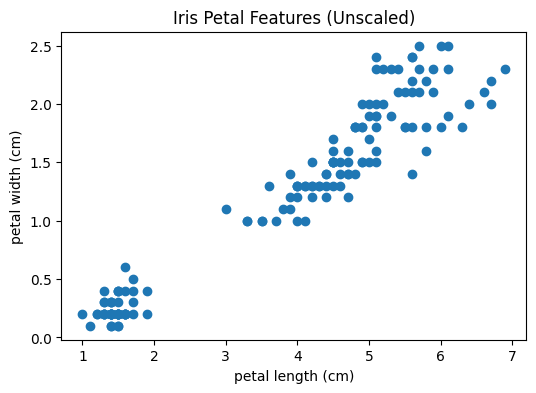

In [2]:
plt.figure(figsize=(6, 4))
plt.scatter(df['petal length (cm)'], df['petal width (cm)'])
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Iris Petal Features (Unscaled)')
plt.show()


## K-Means On Unscaled Features (k=3)


In [3]:
km_unscaled = KMeans(n_clusters=3, random_state=42, n_init='auto')
y_unscaled = km_unscaled.fit_predict(df[feature_cols])

df_unscaled = df.copy()
df_unscaled['cluster'] = y_unscaled
df_unscaled.head()


,petal length (cm),petal width (cm),cluster
0,1.4,0.2,1
1,1.4,0.2,1
2,1.3,0.2,1
3,1.5,0.2,1
4,1.4,0.2,1


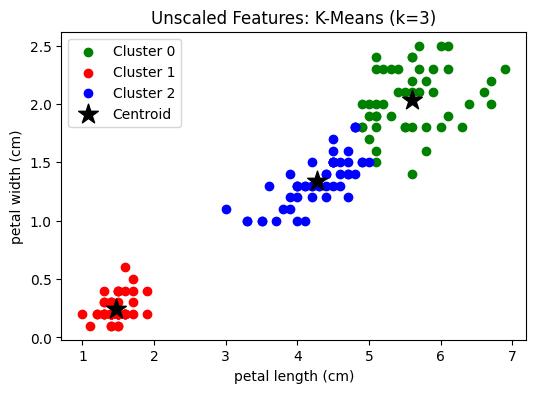

In [4]:
def plot_clusters(ax, data, x_col, y_col, labels, centers, title):
    colors = ['green', 'red', 'blue', 'orange', 'purple']
    for cluster_id in sorted(labels.unique()):
        cluster_points = data[labels == cluster_id]
        ax.scatter(
            cluster_points[x_col],
            cluster_points[y_col],
            color=colors[cluster_id % len(colors)],
            label=f'Cluster {cluster_id}'
        )
    ax.scatter(
        centers[:, 0],
        centers[:, 1],
        color='black',
        marker='*',
        s=220,
        label='Centroid'
    )
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.legend()

fig, ax = plt.subplots(figsize=(6, 4))
plot_clusters(
    ax,
    df_unscaled,
    'petal length (cm)',
    'petal width (cm)',
    df_unscaled['cluster'],
    km_unscaled.cluster_centers_,
    'Unscaled Features: K-Means (k=3)'
)
plt.show()


## Scale Features And Compare Quality


In [5]:
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[feature_cols]), columns=feature_cols)
df_scaled.head()


,petal length (cm),petal width (cm)
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667


In [6]:
km_scaled_k3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
y_scaled_k3 = km_scaled_k3.fit_predict(df_scaled[feature_cols])

sil_unscaled = silhouette_score(df[feature_cols], y_unscaled)
sil_scaled = silhouette_score(df_scaled[feature_cols], y_scaled_k3)

print(f'Silhouette score (unscaled): {sil_unscaled:.4f}')
print(f'Silhouette score (scaled):   {sil_scaled:.4f}')
if sil_scaled > sil_unscaled:
    print('Scaling helps clustering quality for this feature set.')
elif sil_scaled < sil_unscaled:
    print('Scaling does not help clustering quality for this feature set.')
else:
    print('Scaling makes no difference for clustering quality in this run.')


Silhouette score (unscaled): 0.6605
Silhouette score (scaled):   0.6763
Scaling helps clustering quality for this feature set.


## Visual Comparison: Unscaled vs Scaled


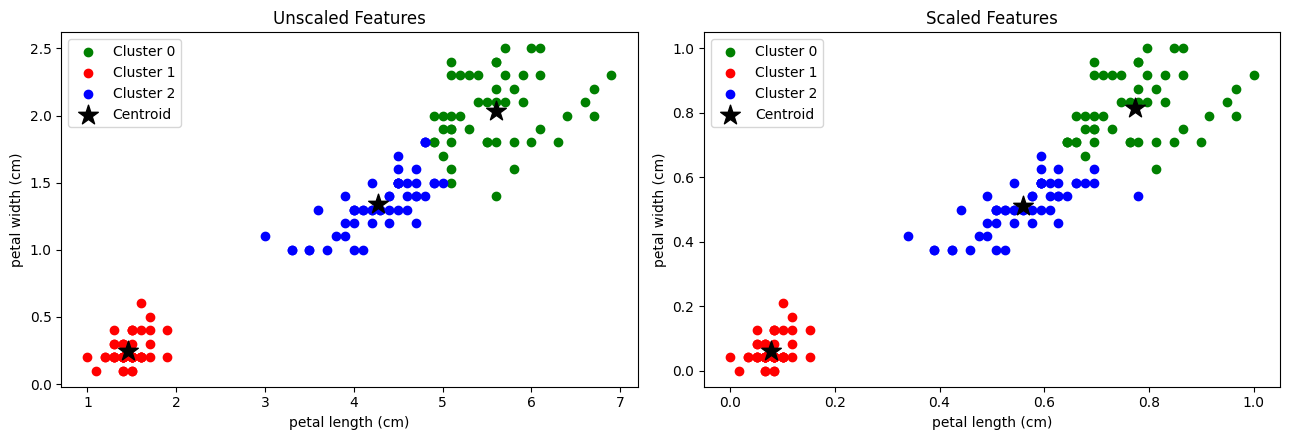

In [7]:
df_scaled_clustered = df_scaled.copy()
df_scaled_clustered['cluster'] = y_scaled_k3

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_clusters(
    axes[0],
    df_unscaled,
    'petal length (cm)',
    'petal width (cm)',
    df_unscaled['cluster'],
    km_unscaled.cluster_centers_,
    'Unscaled Features'
)
plot_clusters(
    axes[1],
    df_scaled_clustered,
    'petal length (cm)',
    'petal width (cm)',
    df_scaled_clustered['cluster'],
    km_scaled_k3.cluster_centers_,
    'Scaled Features'
)
plt.tight_layout()
plt.show()


## Elbow Method On Scaled Data


In [8]:
sse = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(df_scaled[feature_cols])
    sse.append(km.inertia_)

sse


[28.368353219727194,
 5.176463590044368,
 1.7018746881920963,
 1.182656179186675,
 0.9618843938398451,
 0.6889019224531716,
 0.566867830638765,
 0.5416444734655237,
 0.4714234315452125,
 0.4023048492689193]

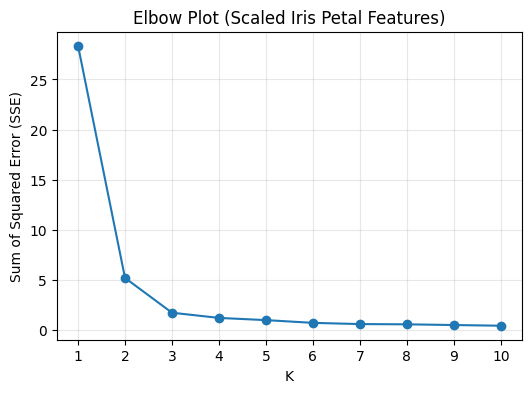

Optimal k from elbow interpretation: 3


In [9]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, sse, marker='o')
plt.xlabel('K')
plt.ylabel('Sum of Squared Error (SSE)')
plt.title('Elbow Plot (Scaled Iris Petal Features)')
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()

optimal_k = 3
print(f'Optimal k from elbow interpretation: {optimal_k}')


## Final Model With Optimal K


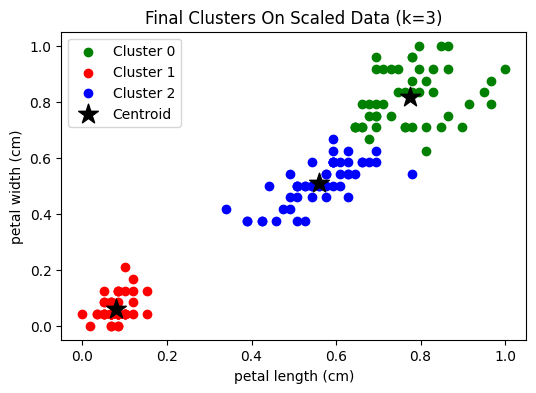

In [10]:
final_km = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
y_final = final_km.fit_predict(df_scaled[feature_cols])

df_final = df_scaled.copy()
df_final['cluster'] = y_final

fig, ax = plt.subplots(figsize=(6, 4))
plot_clusters(
    ax,
    df_final,
    'petal length (cm)',
    'petal width (cm)',
    df_final['cluster'],
    final_km.cluster_centers_,
    f'Final Clusters On Scaled Data (k={optimal_k})'
)
plt.show()
